# Parcel-Facility Join

## 1. read in data

In [1]:
import geopandas as gpd 
import pandas as pd
import numpy as np

# load parcels
parcels = gpd.read_file("assessor_parcels_analytic.geojson")

# load facilities
facilities_gdf = (
    gpd.read_file("major_fac.geojson")
)

## 2. Complete distance-decay weighted join between parcels and facilities

In [2]:
facilities_gdf=facilities_gdf.reset_index().set_index("trifd")
print(facilities_gdf[["name", "air_lbs"]].sort_values("air_lbs"))  # check for zeros before logging

dist = pd.DataFrame(
    {fid: parcels.geometry.distance(geom) / 5280 for fid, geom in facilities_gdf.geometry.items()},
    index=parcels.index,
)  # miles, one column per facility

w_log = np.log10(facilities_gdf["air_lbs"] + 1)
w_log = w_log / w_log.mean()  # mean weight of 1, same scale as unweighted

for lam in [0.5, 1, 2]:
    decay = np.exp(-dist / lam)
    parcels[f"exp_unw_l{lam}"] = decay.sum(axis=1)
    parcels[f"exp_log_l{lam}"] = (decay * w_log).sum(axis=1)  # aligns on trifd

                                                              name    air_lbs
trifd                                                                        
15201MCCNW10948                     MCCONWAY & TORLEY LLC PLT 1801     224.52
1511WTHRML5NRTH  WABTEC COMPONENTS LLC FORMERLY THERMAL TRANSFE...     260.00
15017CYTMPMAYER           UNIVERSAL STAINLESS & ALLOY PRODUCTS INC     488.00
15014LLGHNRIVER              ATI FLAT ROLLED PRODUCTS HOLDINGS LLC    1419.00
15225NVLLC2800N                                NEVILLE CHEMICAL CO   14392.00
15144PPGND125CO               PPG INDUSTRIESINC-SPRINGDALE COMPLEX   22186.09
15104MSDVT13BRA                              TMS INTERNATIONAL LLC   27877.98
15088HRCLSSTATE                      SYNTHOMER JEFFERSON HILLS LLC   50394.00
15034SSRVNPOBOX                 USS MON VALLEY WORKS - IRVIN PLANT   73871.60
15104SSDGRBRADD         USS MON VALLEY WORKS - EDGAR THOMSON PLANT   96883.69
15025SSCLR400ST                                 USS-CLAIRTON PLA

In [3]:
# # inspect results with density plots of each of the decay variables
# import matplotlib.pyplot as plt
# for col in parcels.columns:
#     if col.startswith("exp_"):
#         plt.figure()
#         parcels[col].hist(bins=50, density=True)
#         parcels[col].plot(kind='kde')
#         plt.title(col)
#         plt.show()

## 3. join parcels with census tracts

In [23]:
# download census tract shapefiles

import pygris
from dotenv import load_dotenv
import os
import census as c
from us import states

load_dotenv()
API_KEY = os.getenv("CENSUS_API_KEY")

# alleg = pygris.counties(states.PA.fips).query("NAME == 'Allegheny'").to_crs("EPSG:2272")
allg_tracts = pygris.tracts(states.PA.fips).query("COUNTYFP == '003'").to_crs("EPSG:2272")

Using the default year of 2024


In [27]:
# convert parcels to centroid by dropping geometry column and creating new geom column from lat lon 
# allg_tracts = pygris.tracts(states.PA.fips).query("COUNTYFP == '003'").to_crs("EPSG:2272")
parcels_centroid = parcels.drop(columns="geometry")
# lat/lon are WGS84 degrees (stored as strings), so build the points in EPSG:4326 and reproject to the tracts' CRS
parcels_centroid["geom"] = gpd.points_from_xy(
    parcels_centroid["lon"].astype(float), parcels_centroid["lat"].astype(float)
)
parcels_centroid = gpd.GeoDataFrame(parcels_centroid, geometry="geom", crs="EPSG:4326").to_crs("EPSG:2272")

parcels_centroid = parcels_centroid.drop(columns=["index_right"])
# allg_tracts = allg_tracts.drop(columns=["index_right"])

# join parcels with census tracts 
parcels_with_tracts = gpd.sjoin(
    parcels_centroid, 
    allg_tracts, 
    how="left", predicate="intersects")

# take just parcel id and tract id
parcels_with_tracts = parcels_with_tracts[["parid", "GEOID_right"]].rename(columns={"GEOID_right": "GEOID"})

# rejoin tract info to original parcels file 
parcels = parcels.merge(parcels_with_tracts, on="parid", how="left")

# save new parcels 
parcels.to_file("parcels_with_tracts.geojson", driver="GeoJSON")

In [25]:
parcels_with_tracts

,parid,propertycity,class,classdesc,ownerdesc,grade,saledate,saleprice,countybuilding,countyland,...,GEOID_right,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON
0,0001C00228000400,PITTSBURGH,C,COMMERCIAL,CORPORATION,NaN,02-25-2016,0.0,2144100,0,...,42003020100,1400000US42003020100,201,Census Tract 201,G5020,S,1427891.0,465722.0,+40.4406616,-080.0012770
1,0001D00115000000,PITTSBURGH,C,COMMERCIAL,REGULAR-ETUX OR ET VIR,NaN,12-10-1979,255000.0,177500,155900,...,42003020100,1400000US42003020100,201,Census Tract 201,G5020,S,1427891.0,465722.0,+40.4406616,-080.0012770
2,0001D00117000000,PITTSBURGH,C,COMMERCIAL,CORPORATION,NaN,01-17-2014,1400000.0,16330,588470,...,42003020100,1400000US42003020100,201,Census Tract 201,G5020,S,1427891.0,465722.0,+40.4406616,-080.0012770
3,0001D00125000000,PITTSBURGH,C,COMMERCIAL,CORPORATION,NaN,06-21-2002,1.0,466700,422400,...,42003020100,1400000US42003020100,201,Census Tract 201,G5020,S,1427891.0,465722.0,+40.4406616,-080.0012770
4,0001D00127000000,PITTSBURGH,C,COMMERCIAL,CORPORATION,NaN,06-12-2024,1.0,411700,383200,...,42003020100,1400000US42003020100,201,Census Tract 201,G5020,S,1427891.0,465722.0,+40.4406616,-080.0012770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
584074,1826D00003000000,WEXFORD,R,RESIDENTIAL,REGULAR-ETUX OR ET VIR,C+,06-04-2026,525000.0,159500,62700,...,42003409001,1400000US42003409001,4090.01,Census Tract 4090.01,G5020,S,24155876.0,20971.0,+40.6337250,-080.0383162
584075,1658R00003000000,WEXFORD,C,COMMERCIAL,CORPORATION,NaN,04-05-1999,200000.0,348500,202700,...,42003409001,1400000US42003409001,4090.01,Census Tract 4090.01,G5020,S,24155876.0,20971.0,+40.6337250,-080.0383162
584076,1825R00006000000,WEXFORD,R,RESIDENTIAL,REGULAR,B+,01-10-2023,0.0,341700,77700,...,42003409001,1400000US42003409001,4090.01,Census Tract 4090.01,G5020,S,24155876.0,20971.0,+40.6337250,-080.0383162
584077,1825A00027000000,WEXFORD,R,RESIDENTIAL,REGULAR,C,04-28-2004,1.0,51600,80400,...,42003409001,1400000US42003409001,4090.01,Census Tract 4090.01,G5020,S,24155876.0,20971.0,+40.6337250,-080.0383162


In [6]:
parcels.columns

Index(['parid', 'propertycity', 'class', 'classdesc', 'ownerdesc', 'grade',
       'saledate', 'saleprice', 'countybuilding', 'countyland', 'countytotal',
       'fairmarketbuilding', 'fairmarketland', 'fairmarkettotal', 'taxyear',
       'sale_day', 'sale_month', 'sale_year', '_id', 'map_block_lot',
       'municode', 'calc_acreage', 'comments', 'notes', 'pseudono',
       'shape_length', 'index_right', 'name', 'type', 'region', 'sqmi', 'eoc',
       'lat', 'lon', 'geometry', 'exp_unw_l0.5', 'exp_log_l0.5', 'exp_unw_l1',
       'exp_log_l1', 'exp_unw_l2', 'exp_log_l2', 'GEOID'],
      dtype='str')

In [12]:
parcels

,parid,propertycity,class,classdesc,ownerdesc,grade,saledate,saleprice,countybuilding,countyland,...,exp_log_l1,exp_unw_l2,exp_log_l2,GEOID,exp_unw_l0.5_pct,exp_unw_l1_pct,exp_unw_l2_pct,exp_log_l0.5_pct,exp_log_l1_pct,exp_log_l2_pct
0,0001C00228000400,PITTSBURGH,C,COMMERCIAL,CORPORATION,NaN,02-25-2016,0.0,2144100,0,...,0.022048,0.309772,0.235513,NaN,48.686051,44.575306,45.366808,44.382866,37.587895,37.408981
1,0001D00115000000,PITTSBURGH,C,COMMERCIAL,REGULAR-ETUX OR ET VIR,NaN,12-10-1979,255000.0,177500,155900,...,0.022903,0.313584,0.237857,NaN,49.711426,45.396085,45.993607,45.547435,38.498388,37.990409
2,0001D00117000000,PITTSBURGH,C,COMMERCIAL,CORPORATION,NaN,01-17-2014,1400000.0,16330,588470,...,0.023207,0.314928,0.238634,NaN,50.088772,45.673616,46.215495,45.949435,38.812215,38.175829
3,0001D00125000000,PITTSBURGH,C,COMMERCIAL,CORPORATION,NaN,06-21-2002,1.0,466700,422400,...,0.023635,0.317113,0.240148,NaN,50.623974,46.057811,46.575549,46.473508,39.242123,38.515851
4,0001D00127000000,PITTSBURGH,C,COMMERCIAL,CORPORATION,NaN,06-12-2024,1.0,411700,383200,...,0.023277,0.315532,0.239211,NaN,50.185506,45.738162,46.316680,46.036409,38.887719,38.302182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
584074,1826D00003000000,WEXFORD,R,RESIDENTIAL,REGULAR-ETUX OR ET VIR,C+,06-04-2026,525000.0,159500,62700,...,0.000034,0.008779,0.008022,NaN,1.460933,1.372760,1.387312,1.503393,1.398783,1.364541
584075,1658R00003000000,WEXFORD,C,COMMERCIAL,CORPORATION,NaN,04-05-1999,200000.0,348500,202700,...,0.000115,0.014180,0.013325,NaN,2.963983,2.699292,2.433232,3.083145,2.829069,2.483397
584076,1825R00006000000,WEXFORD,R,RESIDENTIAL,REGULAR,B+,01-10-2023,0.0,341700,77700,...,0.000061,0.010591,0.009904,NaN,2.165289,1.924740,1.722541,2.236684,2.030718,1.763460
584077,1825A00027000000,WEXFORD,R,RESIDENTIAL,REGULAR,C,04-28-2004,1.0,51600,80400,...,0.000040,0.008299,0.007841,NaN,1.697544,1.501509,1.314377,1.760378,1.568281,1.331327


## 4. exploratory visualization and analysis of parcel and facility data

In [7]:
parcels.crs

<Projected CRS: EPSG:2272>
Name: NAD83 / Pennsylvania South (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Pennsylvania - counties of Adams; Allegheny; Armstrong; Beaver; Bedford; Berks; Blair; Bucks; Butler; Cambria; Chester; Cumberland; Dauphin; Delaware; Fayette; Franklin; Fulton; Greene; Huntingdon; Indiana; Juniata; Lancaster; Lawrence; Lebanon; Lehigh; Mifflin; Montgomery; Northampton; Perry; Philadelphia; Schuylkill; Snyder; Somerset; Washington; Westmoreland; York.
- bounds: (-80.53, 39.71, -74.72, 41.18)
Coordinate Operation:
- name: SPCS83 Pennsylvania South zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

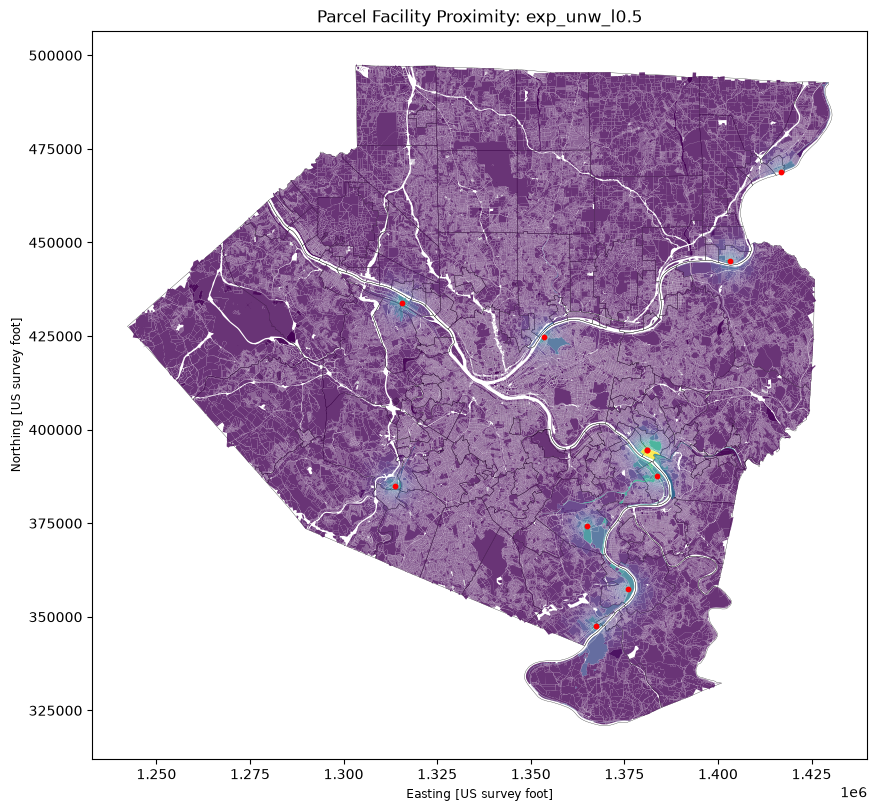

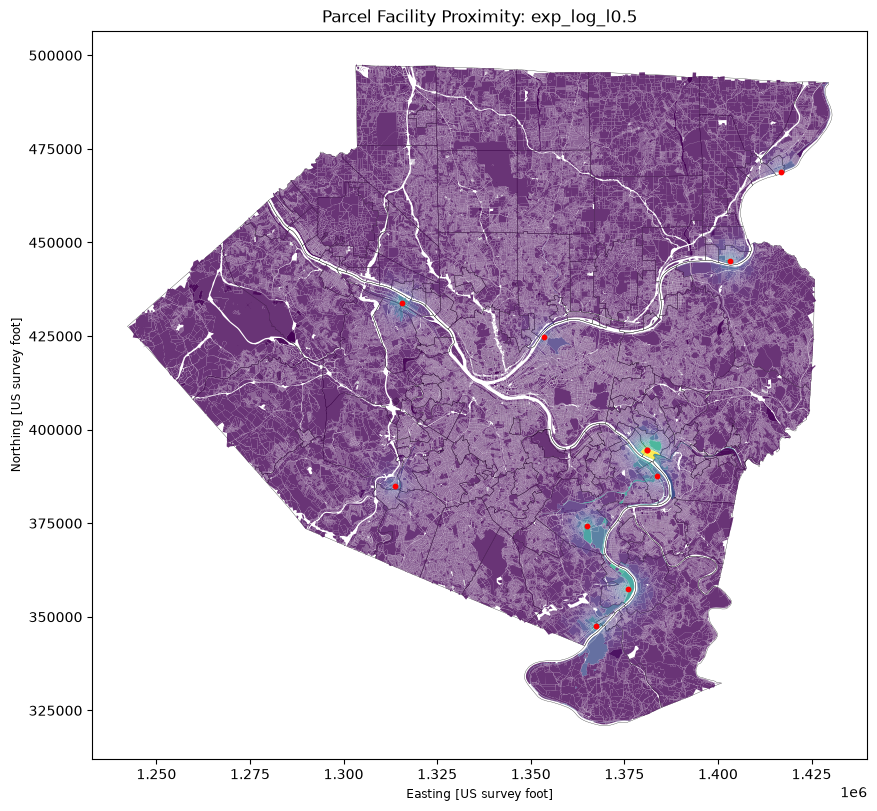

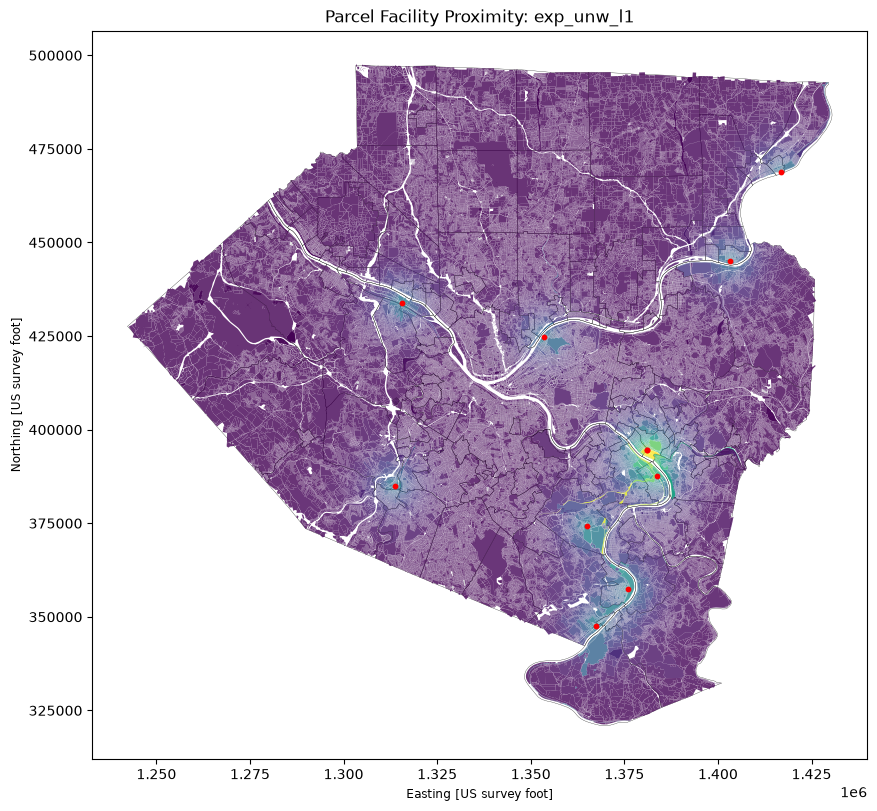

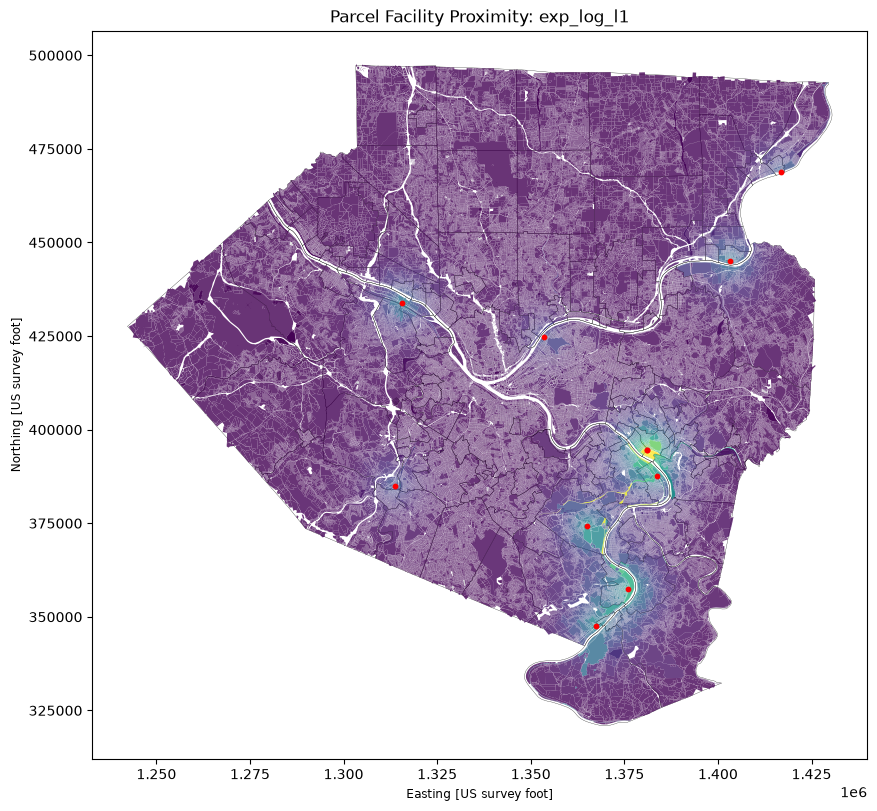

In [8]:
# load municipality boundaries
municipalities = gpd.read_file("allegheny_municipal_boundaries.geojson").to_crs(epsg=2272)

# drop parcels with missing "name" column
parcels = parcels[parcels['name'].notna()]

# static map with 
# 1. parcels, colored by distance-decay weighted facility proximity
# 2. facilities locations 
# 3. Municipality boundaries 

import matplotlib.pyplot as plt

dist_cols = ['exp_unw_l0.5', 'exp_log_l0.5', 'exp_unw_l1', 'exp_log_l1']

for col in dist_cols:
    fig, ax = plt.subplots(figsize=(10, 10))
    municipalities.plot(ax=ax, color='none', edgecolor='black', linewidth=0.2)
    parcels.plot(ax=ax, column=col, cmap='viridis', markersize=5, alpha=0.8)
    facilities_gdf.plot(ax=ax, color='red', markersize=10)
    ax.set_title(f"Parcel Facility Proximity: {col}")
    plt.show()

KeyboardInterrupt: 

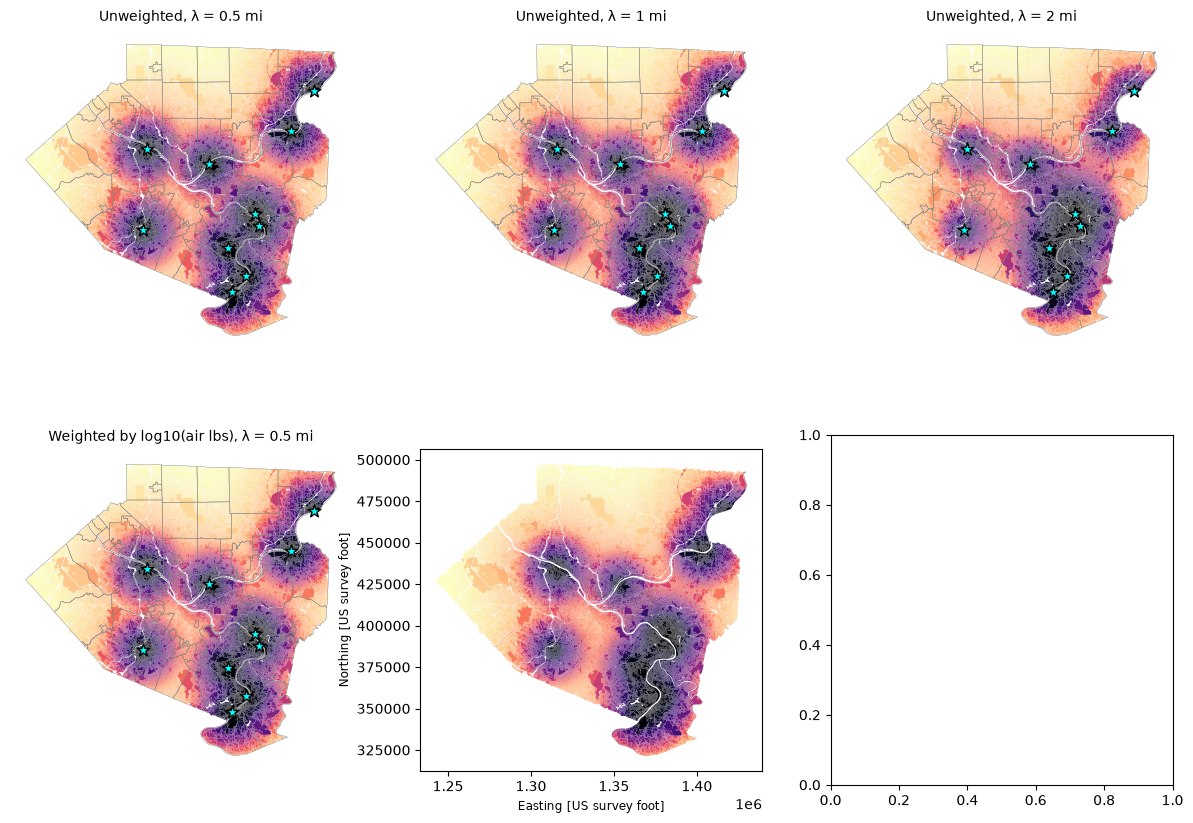

In [11]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import folium
from matplotlib import colormaps
from lonboard import Map, ScatterplotLayer, PolygonLayer
from lonboard.colormap import apply_continuous_cmap

# ---------------------------------------------------------------
# Setup: shared CRS, column names, and labels
# ---------------------------------------------------------------
# Assumes:
#   parcels  - GeoDataFrame of parcel centroids in EPSG:2272 with exp_* columns
#   fac      - the 11 major facilities, EPSG:2272, columns "name" and "air_lbs"
#   municipalities - loaded from allegheny_municipal_boundaries.geojson
MUNI_NAME = "name"  # check municipalities.columns and change to the name column
fac = facilities_gdf

municipalities = municipalities.to_crs(parcels.crs)
LAMS = [0.5, 1, 2]
WEIGHTS = {"unw": "Unweighted", "log": "Weighted by log10(air lbs)"}
SPECS = {f"exp_{w}_l{lam}": f"{label}, λ = {lam} mi"
         for w, label in WEIGHTS.items() for lam in LAMS}
CMAP = "magma_r"

# Raw index values are heavily skewed, so maps show percentile ranks (0-100).
# This also puts every specification on the same color scale.
for col in SPECS:
    parcels[f"{col}_pct"] = parcels[col].rank(pct=True) * 100

# ---------------------------------------------------------------
# 1. Static: small multiples of all six specifications (matplotlib)
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (col, title) in zip(axes.flat, SPECS.items()):
    parcels.plot(ax=ax, column=f"{col}_pct", cmap=CMAP, vmin=0, vmax=100,
                 markersize=0.05, rasterized=True)
    municipalities.boundary.plot(ax=ax, color="grey", linewidth=0.3)
    fac.plot(ax=ax, marker="*", color="cyan", edgecolor="black",
             markersize=90, zorder=5)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(0, 100))
fig.colorbar(sm, ax=axes, shrink=0.6, label="Exposure index percentile")
fig.suptitle("Parcel exposure to major polluters by specification", fontsize=14)
fig.savefig("exposure_small_multiples.png", dpi=300, bbox_inches="tight")

# ---------------------------------------------------------------
# 2. Static: primary specification with basemap and labels (contextily)
# ---------------------------------------------------------------
PRIMARY = "exp_unw_l1"

fig, ax = plt.subplots(figsize=(10, 10))
parcels.plot(ax=ax, column=f"{PRIMARY}_pct", cmap=CMAP, vmin=0, vmax=100,
             markersize=0.05, alpha=0.8, rasterized=True,
             legend=True, legend_kwds={"label": "Exposure index percentile",
                                       "shrink": 0.6})
municipalities.boundary.plot(ax=ax, color="black", linewidth=0.3)
fac.plot(ax=ax, marker="*", color="cyan", edgecolor="black",
         markersize=150, zorder=5)
for name, geom in zip(fac["name"], fac.geometry):
    ax.annotate(name.title(), xy=(geom.x, geom.y), xytext=(5, 5),
                textcoords="offset points", fontsize=7,
                bbox={"facecolor": "white", "alpha": 0.7, "linewidth": 0})
try:
    cx.add_basemap(ax, crs=parcels.crs, source=cx.providers.CartoDB.PositronNoLabels)
except Exception as e:  # basemap tiles need an internet connection
    print("Basemap skipped:", e)
ax.set_title(SPECS[PRIMARY])
ax.set_axis_off()
fig.savefig("exposure_primary.png", dpi=300, bbox_inches="tight")

# ---------------------------------------------------------------
# 3. Interactive: municipality means, one toggleable layer per spec (folium)
# ---------------------------------------------------------------
# 200,000+ points is too many for folium, so aggregate to municipalities.
joined = gpd.sjoin(parcels[list(SPECS) + ["geometry"]],
                   municipalities[[MUNI_NAME, "geometry"]], predicate="within")
muni_means = joined.groupby("index_right")[list(SPECS)].mean()
muni_means["n_parcels"] = joined.groupby("index_right").size()
muni_map = municipalities.join(muni_means)

m = folium.Map(tiles="CartoDB positron")
for i, (col, title) in enumerate(SPECS.items()):
    muni_map[f"{col}_pct"] = muni_map[col].rank(pct=True) * 100
    muni_map.explore(
        m=m, column=f"{col}_pct", cmap=CMAP, vmin=0, vmax=100,
        name=title, show=(col == PRIMARY), legend=(i == 0),
        legend_kwds={"caption": "Municipal mean exposure, percentile"},
        tooltip=[MUNI_NAME, col, "n_parcels"],
        style_kwds={"weight": 0.5, "color": "grey", "fillOpacity": 0.7},
    )
fac.explore(m=m, name="Major facilities", color="cyan",
            marker_kwds={"radius": 7}, style_kwds={"color": "black", "weight": 1},
            tooltip=["name", "air_lbs"])
folium.LayerControl(collapsed=False).add_to(m)
m.fit_bounds(m.get_bounds())
m.save("exposure_municipal.html")
m  # displays in the notebook

# ---------------------------------------------------------------
# 4. Interactive: every parcel, GPU-rendered (lonboard)
# ---------------------------------------------------------------
# lonboard draws hundreds of thousands of points in a notebook.
# It needs EPSG:4326, and colors as an array of RGB values.
parcels_4326 = parcels[[f"{PRIMARY}_pct", "geometry"]].to_crs(4326)

parcel_layer = ScatterplotLayer.from_geopandas(
    parcels_4326,
    get_fill_color=apply_continuous_cmap(
        parcels_4326[f"{PRIMARY}_pct"].to_numpy() / 100, colormaps[CMAP]),
    radius_min_pixels=1,
    radius_max_pixels=3,
)
muni_layer = PolygonLayer.from_geopandas(
    municipalities[[MUNI_NAME, "geometry"]].to_crs(4326),
    filled=False, get_line_color=[90, 90, 90], line_width_min_pixels=0.6,
)
fac_layer = ScatterplotLayer.from_geopandas(
    fac[["name", "air_lbs", "geometry"]].to_crs(4326),
    get_fill_color=[0, 255, 255], get_line_color=[0, 0, 0],
    stroked=True, line_width_min_pixels=1.5, radius_min_pixels=7,
)
lb_map = Map([parcel_layer, muni_layer, fac_layer])
lb_map  # displays in the notebook; click a point to see its attributes